# Proyecto Centinela

## Identificación de Brechas Educativas en Colombia mediante Redes Neuronales Profundas

### Fase 1
### Implementación de un Perceptrón Multicapa (MLP)

---

**Asignatura**

Redes Neuronales y Deep Learning

**Universidad**

Universidad Santo Tomás

Maestría en Ciencia de Datos

---

**Integrantes**

- Oscar Javier Huertas Campo
- Jaidy Viviana Narváez Puyo
- Deison Luis Dimas Hoyos

---


**Fecha**

Julio de 2026

# Introducción

Las brechas educativas representan diferencias significativas en el desempeño académico entre instituciones, regiones y áreas del conocimiento. Estas diferencias limitan la formulación de políticas públicas orientadas a mejorar la calidad de la educación superior.

En este proyecto se propone el desarrollo de un modelo de aprendizaje profundo basado en un Perceptrón Multicapa (MLP) para identificar instituciones con riesgo de bajo desempeño académico utilizando los resultados agregados de las pruebas Saber Pro publicadas por el ICFES.

Esta primera fase se centra en el desarrollo de un modelo tabular utilizando PyTorch. En fases posteriores se incorporarán modalidades adicionales (imágenes derivadas de los datos y series temporales) mediante arquitecturas especializadas de Deep Learning.

# Definición del problema

Las instituciones de educación superior presentan diferencias importantes en sus resultados académicos según la región, el núcleo básico del conocimiento y las características de los programas ofrecidos.

Actualmente el análisis de estos resultados se realiza principalmente mediante estadísticas descriptivas, lo que dificulta identificar patrones complejos asociados al riesgo de bajo desempeño.

Se propone desarrollar un modelo de Deep Learning capaz de clasificar instituciones con riesgo académico utilizando variables agregadas de las pruebas Saber Pro.

# Objetivos

## Objetivo General

Desarrollar un modelo de clasificación basado en un Perceptrón Multicapa (MLP) para identificar instituciones de educación superior con riesgo de bajo desempeño académico utilizando los resultados agregados de las pruebas Saber Pro.

## Objetivos específicos

- Integrar las bases de datos Saber Pro entre 2013 y 2025.
- Realizar el análisis exploratorio del conjunto de datos.
- Preparar la información para el entrenamiento del modelo.
- Implementar un Perceptrón Multicapa utilizando PyTorch.
- Evaluar el desempeño del modelo mediante Accuracy, Precision, Recall, F1-Score y matriz de confusión.

# Descripción del conjunto de datos

Se utilizan las bases de datos abiertas publicadas por el Instituto Colombiano para la Evaluación de la Educación (ICFES), correspondientes a los resultados agregados de las pruebas Saber Pro entre los años 2013 y 2025.

Las bases contienen información agregada por diferentes niveles (institución, sede, departamento, municipio, región y programa académico), así como indicadores de desempeño por competencias, promedios globales, percentiles y niveles de desempeño.

Para esta fase del proyecto se seleccionará un único nivel de agregación con el fin de garantizar consistencia metodológica durante el entrenamiento del modelo.

# Importación de librerías

## Objetivo

Importar las librerías necesarias para el procesamiento de datos, el análisis exploratorio, el preprocesamiento, la construcción del modelo MLP y la evaluación del desempeño.

## Descripción

Se utilizan librerías especializadas en ciencia de datos (Pandas, NumPy), visualización (Matplotlib y Seaborn), aprendizaje automático (Scikit-Learn) y Deep Learning (PyTorch).

In [1]:
# MANIPULACIÓN DE DATOS

import os
import random
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# VISUALIZACIÓN

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

# PREPROCESAMIENTO

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.pipeline import Pipeline

# MÉTRICAS

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# PYTORCH

import torch

import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# Carga del conjunto de datos

## Objetivo

Integrar en un único DataFrame las bases de datos abiertas de resultados agregados Saber Pro publicadas por el ICFES.

## Descripción

Se cargan automáticamente todas las bases disponibles correspondientes al periodo 2013–2025 y posteriormente se consolidan en un único conjunto de datos para su análisis.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
ruta = "/content/drive/MyDrive/Proyecto_Centinela/data/raw"

In [4]:
archivos = sorted(
    [f for f in os.listdir(ruta) if f.endswith(".xlsx")]
)

print(f"Archivos encontrados: {len(archivos)}")

for archivo in archivos:
    print(archivo)

Archivos encontrados: 12
2026-05-11-base-de-datos-de-resultados-agregados-de-saber-pro-2025.xlsx
Base-de-datos-de-resultados-agregados-de-saber-pro-2019-1.xlsx
Base-de-datos-de-resultados-agregados-de-saber-pro-2020.xlsx
Base-de-datos-de-resultados-agregados-de-saber-pro-2021.xlsx
Base-de-datos-de-resultados-agregados-de-saber-pro-2022.xlsx
Base-de-datos-de-resultados-agregados-de-saber-pro-2023.xlsx
Base-de-datos-de-resultados-agregados-de-saber-pro-2024.xlsx
Reporte-resultados-agregados-saber-pro-2013-competencias-genericas.xlsx
Reporte-resultados-agregados-saber-pro-2014-competencias-especificas-v2.xlsx
Reporte-resultados-agregados-saber-pro-2015-competencias-especificas.xlsx
Resultados-agregados-saber-pro-2018-1.xlsx
Resultados-agregados-saber-pro-modulos-especificos-2016.xlsx


In [5]:
estructuras = {}

for archivo in archivos:

    ruta_archivo = os.path.join(ruta, archivo)

    try:

        temp = pd.read_excel(
            ruta_archivo,
            nrows=5
        )

        estructuras[archivo] = temp.columns.tolist()

    except Exception as e:

        print(archivo)
        print(e)

In [6]:
referencia = list(estructuras.values())[0]

for nombre, columnas in estructuras.items():

    if columnas == referencia:

        print(f"✅ {nombre}")

    else:

        print(f"❌ {nombre}")

✅ 2026-05-11-base-de-datos-de-resultados-agregados-de-saber-pro-2025.xlsx
❌ Base-de-datos-de-resultados-agregados-de-saber-pro-2019-1.xlsx
✅ Base-de-datos-de-resultados-agregados-de-saber-pro-2020.xlsx
✅ Base-de-datos-de-resultados-agregados-de-saber-pro-2021.xlsx
✅ Base-de-datos-de-resultados-agregados-de-saber-pro-2022.xlsx
✅ Base-de-datos-de-resultados-agregados-de-saber-pro-2023.xlsx
✅ Base-de-datos-de-resultados-agregados-de-saber-pro-2024.xlsx
❌ Reporte-resultados-agregados-saber-pro-2013-competencias-genericas.xlsx
❌ Reporte-resultados-agregados-saber-pro-2014-competencias-especificas-v2.xlsx
❌ Reporte-resultados-agregados-saber-pro-2015-competencias-especificas.xlsx
❌ Resultados-agregados-saber-pro-2018-1.xlsx
❌ Resultados-agregados-saber-pro-modulos-especificos-2016.xlsx


In [7]:
for nombre, columnas in estructuras.items():
    ...

# Integración del conjunto de datos

Se integran las bases de datos correspondientes al periodo 2020–2025, ya que presentan una estructura homogénea de variables, lo que garantiza la consistencia del proceso de entrenamiento y evaluación del modelo.

In [8]:
# UNIFICAR BASES 2020-2025

dfs = []

for archivo in archivos:

    if any(str(anio) in archivo for anio in range(2020, 2026)):

        print(f"Leyendo {archivo}")

        ruta_archivo = os.path.join(ruta, archivo)

        temp = pd.read_excel(ruta_archivo)

        dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("\nBase consolidada.")
print(df.shape)

Leyendo 2026-05-11-base-de-datos-de-resultados-agregados-de-saber-pro-2025.xlsx
Leyendo Base-de-datos-de-resultados-agregados-de-saber-pro-2020.xlsx
Leyendo Base-de-datos-de-resultados-agregados-de-saber-pro-2021.xlsx
Leyendo Base-de-datos-de-resultados-agregados-de-saber-pro-2022.xlsx
Leyendo Base-de-datos-de-resultados-agregados-de-saber-pro-2023.xlsx
Leyendo Base-de-datos-de-resultados-agregados-de-saber-pro-2024.xlsx

Base consolidada.
(2102295, 34)


In [9]:
df.head()

,EXAMEN,AGREGACION,MEDIDA_AGREGACION,CANTIDADEVALUADOS,ID_PAIS,ID_REGION,NOMBRE_REGION,ID_DEPARTAMENTO,NOMBRE_DEPARTAMENTO,ID_MUNICIPIO,...,PROMEDIO_PRUEBA,DESVIACION,PROMEDIO_PERCENTIL,NIVEL1,NIVEL2,NIVEL3,NIVEL4,NIVEL5,AFIRMACION,PORCENTAJERTAINCORRECTA
0,SABER PRO - 2025,DEPARTAMENTO,NIVEL_DESEMPEÑO_PRUEBA,38,1,1.0,AMAZONÍA,8.0,CAQUETA,NaN,...,NaN,NaN,NaN,21.0,32.0,45.0,3.0,NaN,NaN,NaN
1,SABER PRO - 2025,DEPARTAMENTO,NIVEL_DESEMPEÑO_PRUEBA,1020,1,1.0,AMAZONÍA,8.0,CAQUETA,NaN,...,NaN,NaN,NaN,21.0,58.0,15.0,6.0,NaN,NaN,NaN
2,SABER PRO - 2025,DEPARTAMENTO,NIVEL_DESEMPEÑO_PRUEBA,56,1,1.0,AMAZONÍA,8.0,CAQUETA,NaN,...,NaN,NaN,NaN,30.0,46.0,20.0,4.0,NaN,NaN,NaN
3,SABER PRO - 2025,DEPARTAMENTO,NIVEL_DESEMPEÑO_PRUEBA,21,1,1.0,AMAZONÍA,8.0,CAQUETA,NaN,...,NaN,NaN,NaN,24.0,48.0,29.0,0.0,NaN,NaN,NaN
4,SABER PRO - 2025,DEPARTAMENTO,NIVEL_DESEMPEÑO_PRUEBA,13,1,1.0,AMAZONÍA,8.0,CAQUETA,NaN,...,NaN,NaN,NaN,8.0,85.0,8.0,0.0,NaN,NaN,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2102295 entries, 0 to 2102294
Data columns (total 34 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   EXAMEN                   object 
 1   AGREGACION               object 
 2   MEDIDA_AGREGACION        object 
 3   CANTIDADEVALUADOS        int64  
 4   ID_PAIS                  int64  
 5   ID_REGION                float64
 6   NOMBRE_REGION            object 
 7   ID_DEPARTAMENTO          float64
 8   NOMBRE_DEPARTAMENTO      object 
 9   ID_MUNICIPIO             float64
 10  NOMBRE_MUNICIPIO         object 
 11  ID_INSTITUCION           float64
 12  NOMBRE_INSTITUCION       object 
 13  ID_SEDE                  float64
 14  NOMBRE_SEDE              object 
 15  ID_GRUPOREFERENCIA       float64
 16  NOMBRE_GRUPOREF          object 
 17  ID_NBC                   float64
 18  NBC                      object 
 19  ID_PROGRAMA_ACAD         float64
 20  NOMBRE_PROGRAMA_ACAD     object 
 21  NOMBRE_P

# Selección del nivel de agregación

## Justificación

Las bases Saber Pro contienen información agregada en diferentes niveles
(región, departamento, municipio, institución, sede y programa académico).

Para evitar mezclar observaciones de distinta naturaleza y garantizar la
consistencia del modelo de clasificación, en esta primera fase se trabajará
únicamente con la agregación **INSTITUCIÓN**, ya que representa un nivel
homogéneo de análisis y permite comparar el desempeño institucional entre
diferentes regiones del país.

In [11]:
df["AGREGACION"].value_counts()

,count
AGREGACION,
PROGRAMA_ACÁDEMICO,723656
NBC_SEDE,572380
NBC_INSTITUCION,511414
SEDE,131319
INSTITUCIÓN,113458
MUNICIPIO,20953
DEPARTAMENTO,13211
NBC,12005
REGIÓN,2755


In [12]:
print(df.shape)

print()

print(df["PROMEDIO_GLOBAL"].describe())

(2102295, 34)

count    57519.000000
mean       149.550792
std         16.380689
min          0.000000
25%        138.000000
50%        148.000000
75%        159.000000
max        240.000000
Name: PROMEDIO_GLOBAL, dtype: float64


In [13]:
print(df["PROMEDIO_GLOBAL"].isna().sum())

2044776


In [14]:
print(df["PROMEDIO_GLOBAL"].notna().sum())

57519


In [15]:
# DISPONIBILIDAD DE PROMEDIO_GLOBAL
# POR NIVEL DE AGREGACIÓN

resumen = (
    df.groupby("AGREGACION")["PROMEDIO_GLOBAL"]
      .agg(
          total="size",
          con_promedio=lambda x: x.notna().sum(),
          sin_promedio=lambda x: x.isna().sum()
      )
)

resumen["porcentaje_con_promedio"] = (
    resumen["con_promedio"] / resumen["total"] * 100
).round(2)

resumen.sort_values("con_promedio", ascending=False)

,total,con_promedio,sin_promedio,porcentaje_con_promedio
AGREGACION,,,,
PROGRAMA_ACÁDEMICO,723656,24683,698973,3.41
NBC_SEDE,572380,15331,557049,2.68
NBC_INSTITUCION,511414,13679,497735,2.67
SEDE,131319,1595,129724,1.21
INSTITUCIÓN,113458,1340,112118,1.18
MUNICIPIO,20953,363,20590,1.73
NBC,12005,336,11669,2.80
DEPARTAMENTO,13211,156,13055,1.18
REGIÓN,2755,30,2725,1.09


In [16]:
# Volvemos a leer la base consolidada SIN filtrar
df_total = pd.concat(dfs, ignore_index=True)

resumen = (
    df_total.groupby("AGREGACION")["PROMEDIO_GLOBAL"]
      .agg(
          total="size",
          con_promedio=lambda x: x.notna().sum(),
          sin_promedio=lambda x: x.isna().sum()
      )
)

resumen["porcentaje_con_promedio"] = (
    resumen["con_promedio"] / resumen["total"] * 100
).round(2)

resumen.sort_values("con_promedio", ascending=False)

,total,con_promedio,sin_promedio,porcentaje_con_promedio
AGREGACION,,,,
PROGRAMA_ACÁDEMICO,723656,24683,698973,3.41
NBC_SEDE,572380,15331,557049,2.68
NBC_INSTITUCION,511414,13679,497735,2.67
SEDE,131319,1595,129724,1.21
INSTITUCIÓN,113458,1340,112118,1.18
MUNICIPIO,20953,363,20590,1.73
NBC,12005,336,11669,2.80
DEPARTAMENTO,13211,156,13055,1.18
REGIÓN,2755,30,2725,1.09


In [17]:
df = df_total[
    df_total["AGREGACION"] == "PROGRAMA_ACADÉMICO"
].copy()

print(df.shape)

(0, 34)


In [18]:
df_total["AGREGACION"].unique()

array(['DEPARTAMENTO', 'INSTITUCIÓN', 'MUNICIPIO', 'NBC',
       'NBC_INSTITUCION', 'NBC_SEDE ', 'PAIS', 'PROGRAMA_ACÁDEMICO',
       'REGIÓN', 'SEDE'], dtype=object)

In [19]:
for valor in sorted(df_total["AGREGACION"].unique()):
    print(repr(valor))

'DEPARTAMENTO'
'INSTITUCIÓN'
'MUNICIPIO'
'NBC'
'NBC_INSTITUCION'
'NBC_SEDE '
'PAIS'
'PROGRAMA_ACÁDEMICO'
'REGIÓN'
'SEDE'


In [20]:
print(df_total.shape)

(2102295, 34)


In [21]:
df_total["AGREGACION"].value_counts()

,count
AGREGACION,
PROGRAMA_ACÁDEMICO,723656
NBC_SEDE,572380
NBC_INSTITUCION,511414
SEDE,131319
INSTITUCIÓN,113458
MUNICIPIO,20953
DEPARTAMENTO,13211
NBC,12005
REGIÓN,2755


In [22]:
valor_programa = df_total["AGREGACION"].value_counts().index[0]

df = df_total.loc[
    df_total["AGREGACION"] == valor_programa
].copy()

In [23]:
df_total[df_total["AGREGACION"].str.contains("PROGRAMA", na=False)]

,EXAMEN,AGREGACION,MEDIDA_AGREGACION,CANTIDADEVALUADOS,ID_PAIS,ID_REGION,NOMBRE_REGION,ID_DEPARTAMENTO,NOMBRE_DEPARTAMENTO,ID_MUNICIPIO,...,PROMEDIO_PRUEBA,DESVIACION,PROMEDIO_PERCENTIL,NIVEL1,NIVEL2,NIVEL3,NIVEL4,NIVEL5,AFIRMACION,PORCENTAJERTAINCORRECTA
219371,SABER PRO - 2025,PROGRAMA_ACÁDEMICO,APRENDIZAJE_PRUEBA,661,1,1.0,AMAZONÍA,8.0,CAQUETA,349.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Reflexiona a partir de un texto y evalúa su co...,50.0
219372,SABER PRO - 2025,PROGRAMA_ACÁDEMICO,APRENDIZAJE_PRUEBA,240,1,1.0,AMAZONÍA,8.0,CAQUETA,349.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Comprende que los problemas y sus soluciones i...,51.0
219373,SABER PRO - 2025,PROGRAMA_ACÁDEMICO,APRENDIZAJE_PRUEBA,6,1,1.0,AMAZONÍA,8.0,CAQUETA,349.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Comprende que los problemas y sus soluciones i...,100.0
219374,SABER PRO - 2025,PROGRAMA_ACÁDEMICO,APRENDIZAJE_PRUEBA,69,1,1.0,AMAZONÍA,8.0,CAQUETA,349.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Conoce los derechos y deberes que la Constituc...,52.0
219375,SABER PRO - 2025,PROGRAMA_ACÁDEMICO,APRENDIZAJE_PRUEBA,468,1,1.0,AMAZONÍA,8.0,CAQUETA,349.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Diseña proyectos curriculares, planes de estud...",62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2072244,SABER PRO - 2024,PROGRAMA_ACÁDEMICO,PUNTAJE_PRUEBA,10,1,6.0,PACÍFICA,25.0,VALLE,1045.0,...,146.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2072245,SABER PRO - 2024,PROGRAMA_ACÁDEMICO,PUNTAJE_PRUEBA,53,1,6.0,PACÍFICA,25.0,VALLE,1045.0,...,138.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2072246,SABER PRO - 2024,PROGRAMA_ACÁDEMICO,PUNTAJE_PRUEBA,13,1,6.0,PACÍFICA,25.0,VALLE,1045.0,...,140.0,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2072247,SABER PRO - 2024,PROGRAMA_ACÁDEMICO,PUNTAJE_PRUEBA,3,1,6.0,PACÍFICA,25.0,VALLE,1045.0,...,166.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
print(
    df_total["AGREGACION"].str.contains("PROGRAMA", na=False).sum()
)

723656


In [25]:
print(df_total.shape)

(2102295, 34)


In [26]:
df_total["AGREGACION"].value_counts()

,count
AGREGACION,
PROGRAMA_ACÁDEMICO,723656
NBC_SEDE,572380
NBC_INSTITUCION,511414
SEDE,131319
INSTITUCIÓN,113458
MUNICIPIO,20953
DEPARTAMENTO,13211
NBC,12005
REGIÓN,2755


In [27]:
print(
    df_total["AGREGACION"].str.contains("PROGRAMA", na=False).sum()
)

723656


In [28]:
mask = df_total["AGREGACION"] == "PROGRAMA_ACADÉMICO"

print(mask.sum())

0


In [29]:
df = df_total[mask].copy()

print(df.shape)

(0, 34)


In [30]:
valor = df_total["AGREGACION"].value_counts().index[0]

print(valor)
print(len(valor))
print([c for c in valor])

PROGRAMA_ACÁDEMICO
18
['P', 'R', 'O', 'G', 'R', 'A', 'M', 'A', '_', 'A', 'C', 'Á', 'D', 'E', 'M', 'I', 'C', 'O']


# Selección del nivel de agregación

## Decisión metodológica

Durante el análisis exploratorio se evaluaron los diferentes niveles de agregación disponibles en las bases de datos del ICFES (país, región, departamento, municipio, institución, sede, NBC y programa académico).

Inicialmente se planteó utilizar la agregación **INSTITUCIÓN**; sin embargo, el análisis mostró que la variable **PROMEDIO_GLOBAL** presentaba un porcentaje muy alto de valores faltantes en este nivel, lo que limitaba considerablemente la cantidad de observaciones disponibles para entrenar el modelo.

Posteriormente se evaluó la agregación **PROGRAMA_ACADÉMICO**, encontrando que este nivel concentra la mayor cantidad de registros con información válida del promedio global, permitiendo construir un conjunto de datos mucho más robusto para el entrenamiento de la red neuronal.

In [31]:
# DECISIÓN METODOLÓGICA (DESCARTADA)

# Inicialmente se trabajó con la agregación INSTITUCIÓN.
# Esta alternativa fue descartada debido a la gran cantidad
# de registros sin información en PROMEDIO_GLOBAL.

# df = df_total[
#     df_total["AGREGACION"] == "INSTITUCIÓN"
# ].copy()

In [32]:
# DECISIÓN METODOLÓGICA DEFINITIVA

# Se selecciona la agregación PROGRAMA_ACADÉMICO porque
# presenta el mayor número de registros con información
# válida para entrenar el modelo.

df = df_total.loc[
    df_total["AGREGACION"] == "PROGRAMA_ACADÉMICO"
].copy()

print(df.shape)

(0, 34)


In [33]:
mask = df_total["AGREGACION"] == "PROGRAMA_ACADÉMICO"

print(mask.sum())

0


In [34]:
print(df_total.shape)

(2102295, 34)


In [35]:
print(df_total["AGREGACION"].value_counts())

AGREGACION
PROGRAMA_ACÁDEMICO    723656
NBC_SEDE              572380
NBC_INSTITUCION       511414
SEDE                  131319
INSTITUCIÓN           113458
MUNICIPIO              20953
DEPARTAMENTO           13211
NBC                    12005
REGIÓN                  2755
PAIS                    1144
Name: count, dtype: int64


In [36]:
print(df_total.head())

             EXAMEN    AGREGACION       MEDIDA_AGREGACION  CANTIDADEVALUADOS  \
0  SABER PRO - 2025  DEPARTAMENTO  NIVEL_DESEMPEÑO_PRUEBA                 38   
1  SABER PRO - 2025  DEPARTAMENTO  NIVEL_DESEMPEÑO_PRUEBA               1020   
2  SABER PRO - 2025  DEPARTAMENTO  NIVEL_DESEMPEÑO_PRUEBA                 56   
3  SABER PRO - 2025  DEPARTAMENTO  NIVEL_DESEMPEÑO_PRUEBA                 21   
4  SABER PRO - 2025  DEPARTAMENTO  NIVEL_DESEMPEÑO_PRUEBA                 13   

   ID_PAIS  ID_REGION NOMBRE_REGION  ID_DEPARTAMENTO NOMBRE_DEPARTAMENTO  \
0        1        1.0      AMAZONÍA              8.0             CAQUETA   
1        1        1.0      AMAZONÍA              8.0             CAQUETA   
2        1        1.0      AMAZONÍA              8.0             CAQUETA   
3        1        1.0      AMAZONÍA              8.0             CAQUETA   
4        1        1.0      AMAZONÍA              8.0             CAQUETA   

   ID_MUNICIPIO  ... PROMEDIO_PRUEBA  DESVIACION PROMEDIO_PERC

In [37]:
valor_programa = df_total["AGREGACION"].value_counts().index[0]

print(valor_programa)

PROGRAMA_ACÁDEMICO


In [38]:
mask = df_total["AGREGACION"] == valor_programa

print(mask.sum())

723656


In [39]:
df = df_total.loc[
    df_total["AGREGACION"] == valor_programa
].copy()

print(df.shape)

(723656, 34)


In [40]:
# Se utiliza el valor obtenido directamente del DataFrame para
# evitar posibles diferencias de codificación Unicode en caracteres
# acentuados.
valor_programa = df_total["AGREGACION"].value_counts().index[0]

df = df_total[df_total["AGREGACION"] == valor_programa].copy()

# Calidad de los datos

## Objetivo

Antes de construir la variable objetivo del modelo, se analiza la calidad del conjunto de datos seleccionado.

En esta etapa se identifican:

- Valores faltantes.
- Variables disponibles para el entrenamiento.
- Distribución de la variable PROMEDIO_GLOBAL.

Este análisis permite justificar las decisiones de limpieza de datos y garantizar que el entrenamiento se realice sobre información consistente.

In [41]:
# ANÁLISIS DE VALORES FALTANTES

faltantes = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

faltantes = faltantes[faltantes > 0]

display(faltantes)

,0
PROMEDIO_PERCENTIL,723656
NIVEL5,719545
PROMEDIO_GLOBAL,698973
NIVEL4,574620
NIVEL3,574620
NIVEL2,574620
NIVEL1,574620
PROMEDIO_PRUEBA,567438
DESVIACION,545055
ID_NBC,343968


In [42]:
porcentaje = (
    df.isnull()
      .mean()*100
).sort_values(ascending=False)

porcentaje = porcentaje[porcentaje > 0]

display(porcentaje.round(2))

,0
PROMEDIO_PERCENTIL,100.00
NIVEL5,99.43
PROMEDIO_GLOBAL,96.59
NIVEL4,79.41
NIVEL3,79.41
NIVEL2,79.41
NIVEL1,79.41
PROMEDIO_PRUEBA,78.41
DESVIACION,75.32
ID_NBC,47.53


In [43]:
print(df["PROMEDIO_GLOBAL"].describe())

count    24683.000000
mean       148.795811
std         16.964793
min          0.000000
25%        137.000000
50%        147.000000
75%        159.000000
max        240.000000
Name: PROMEDIO_GLOBAL, dtype: float64


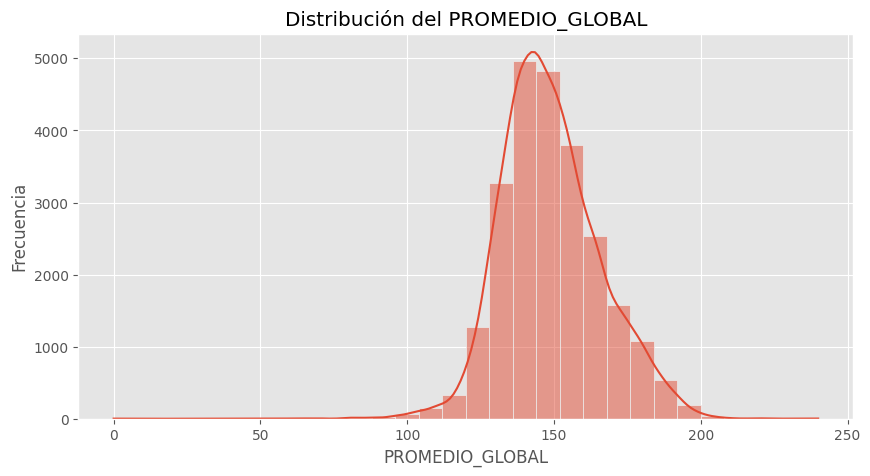

In [44]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["PROMEDIO_GLOBAL"],
    bins=30,
    kde=True
)

plt.title("Distribución del PROMEDIO_GLOBAL")
plt.xlabel("PROMEDIO_GLOBAL")
plt.ylabel("Frecuencia")

plt.show()

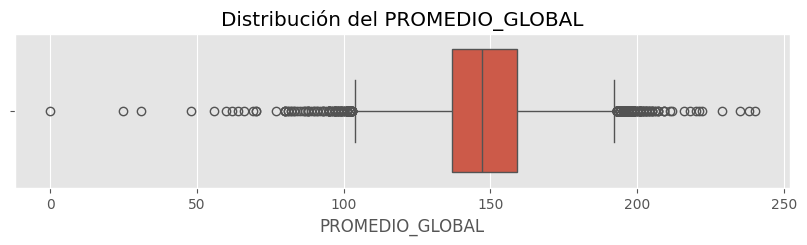

In [45]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["PROMEDIO_GLOBAL"]
)

plt.title("Distribución del PROMEDIO_GLOBAL")

plt.show()

In [46]:
umbral25 = df["PROMEDIO_GLOBAL"].quantile(0.25)

print(umbral25)

137.0


In [47]:
umbral30 = df["PROMEDIO_GLOBAL"].quantile(0.30)

print(umbral30)

139.0


In [48]:
umbral35 = df["PROMEDIO_GLOBAL"].quantile(0.35)

print(umbral35)

141.0


In [49]:
for nombre, umbral in {
    "25%": umbral25,
    "30%": umbral30,
    "35%": umbral35
}.items():

    riesgo = (df["PROMEDIO_GLOBAL"] < umbral).astype(int)

    print("="*40)
    print(nombre)
    print(riesgo.value_counts(normalize=True).round(3))

25%
PROMEDIO_GLOBAL
0    0.992
1    0.008
Name: proportion, dtype: float64
30%
PROMEDIO_GLOBAL
0    0.99
1    0.01
Name: proportion, dtype: float64
35%
PROMEDIO_GLOBAL
0    0.989
1    0.011
Name: proportion, dtype: float64


Se evaluaron distintos umbrales basados en percentiles (25 %, 30 % y 35 %); sin embargo, la distribución discreta de los puntajes produjo una proporción muy similar de observaciones clasificadas como riesgo en todos los escenarios, por lo que el simple ajuste del percentil no resolvió el desbalance de clases.

In [50]:
# DISTRIBUCIÓN DE LOS PUNTAJES

conteo = (
    df["PROMEDIO_GLOBAL"]
      .value_counts()
      .sort_index()
)

display(conteo.head(30))

,count
PROMEDIO_GLOBAL,
0.0,1
25.0,1
31.0,1
48.0,1
56.0,1
60.0,1
62.0,1
64.0,1
66.0,1


In [51]:
conteo.tail(30)

,count
PROMEDIO_GLOBAL,
190.0,48
191.0,53
192.0,33
193.0,47
194.0,23
195.0,21
196.0,23
197.0,15
198.0,10


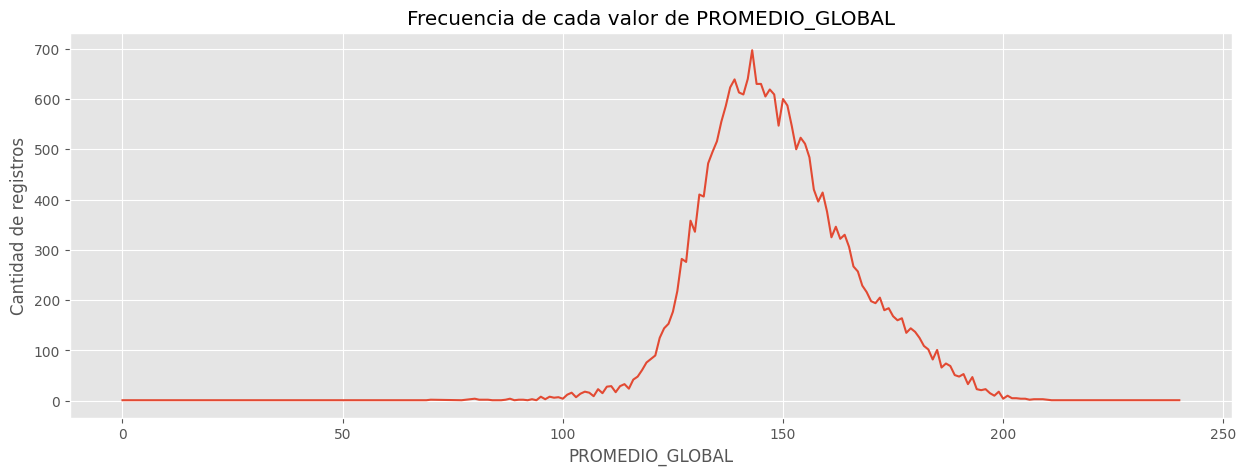

In [52]:
plt.figure(figsize=(15,5))

conteo.plot()

plt.title("Frecuencia de cada valor de PROMEDIO_GLOBAL")
plt.xlabel("PROMEDIO_GLOBAL")
plt.ylabel("Cantidad de registros")

plt.show()

In [53]:
for col in df.columns:
    print(col)

EXAMEN
AGREGACION
MEDIDA_AGREGACION
CANTIDADEVALUADOS
ID_PAIS
ID_REGION
NOMBRE_REGION
ID_DEPARTAMENTO
NOMBRE_DEPARTAMENTO
ID_MUNICIPIO
NOMBRE_MUNICIPIO
ID_INSTITUCION
NOMBRE_INSTITUCION
ID_SEDE
NOMBRE_SEDE
ID_GRUPOREFERENCIA
NOMBRE_GRUPOREF
ID_NBC
NBC
ID_PROGRAMA_ACAD
NOMBRE_PROGRAMA_ACAD
NOMBRE_PRUEBA
CATEGORIAPRUEBA
PROMEDIO_GLOBAL
PROMEDIO_PRUEBA
DESVIACION
PROMEDIO_PERCENTIL
NIVEL1
NIVEL2
NIVEL3
NIVEL4
NIVEL5
AFIRMACION
PORCENTAJERTAINCORRECTA


In [54]:
for umbral in [140, 145, 150]:

    riesgo = (df["PROMEDIO_GLOBAL"] < umbral).astype(int)

    print("="*50)
    print(f"Umbral: {umbral}")
    print(riesgo.value_counts())
    print()
    print(riesgo.value_counts(normalize=True).round(3))

Umbral: 140
PROMEDIO_GLOBAL
0    716117
1      7539
Name: count, dtype: int64

PROMEDIO_GLOBAL
0    0.99
1    0.01
Name: proportion, dtype: float64
Umbral: 145
PROMEDIO_GLOBAL
0    712928
1     10728
Name: count, dtype: int64

PROMEDIO_GLOBAL
0    0.985
1    0.015
Name: proportion, dtype: float64
Umbral: 150
PROMEDIO_GLOBAL
0    709918
1     13738
Name: count, dtype: int64

PROMEDIO_GLOBAL
0    0.981
1    0.019
Name: proportion, dtype: float64


In [55]:
umbral = df["PROMEDIO_GLOBAL"].quantile(0.25)

df["RIESGO"] = (
    df["PROMEDIO_GLOBAL"] < umbral
).astype(int)

In [56]:
print(df["MEDIDA_AGREGACION"].value_counts())

MEDIDA_AGREGACION
APRENDIZAJE_PRUEBA        393719
PUNTAJE_PRUEBA            156218
NIVEL_DESEMPEÑO_PRUEBA    149036
PUNTAJE_GLOBAL             24683
Name: count, dtype: int64


In [57]:
# SELECCIÓN DE LA MEDIDA DE AGREGACIÓN

# El ICFES publica diferentes tipos de indicadores para
# cada programa académico.
#
# En este proyecto se utilizará únicamente la medida
# PUNTAJE_GLOBAL, ya que corresponde al promedio global
# obtenido por cada programa y es la variable necesaria
# para construir la etiqueta de riesgo.

In [58]:
df = df[
    df["MEDIDA_AGREGACION"] == "PUNTAJE_GLOBAL"
].copy()

print(df.shape)

(24683, 35)


In [59]:
print(df["PROMEDIO_GLOBAL"].isna().sum())

0


In [60]:
print(df["RIESGO"].value_counts())

print()

print(df["RIESGO"].value_counts(normalize=True).round(3))

RIESGO
0    18992
1     5691
Name: count, dtype: int64

RIESGO
0    0.769
1    0.231
Name: proportion, dtype: float64


In [61]:
faltantes = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

faltantes[faltantes > 0]

,0
NIVEL3,24683
NIVEL2,24683
NIVEL1,24683
NOMBRE_PRUEBA,24683
PROMEDIO_PERCENTIL,24683
CATEGORIAPRUEBA,24683
NIVEL4,24683
PROMEDIO_PRUEBA,24683
PORCENTAJERTAINCORRECTA,24683
AFIRMACION,24683


In [62]:
df.dtypes

,0
EXAMEN,object
AGREGACION,object
MEDIDA_AGREGACION,object
CANTIDADEVALUADOS,int64
ID_PAIS,int64
ID_REGION,float64
NOMBRE_REGION,object
ID_DEPARTAMENTO,float64
NOMBRE_DEPARTAMENTO,object
ID_MUNICIPIO,float64


In [63]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CANTIDADEVALUADOS,24683.0,61.111737,143.178528,1.0,14.0,33.0,67.0,4074.0
ID_PAIS,24683.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
ID_REGION,24683.0,2.693190,1.364427,1.0,2.0,2.0,3.0,6.0
ID_DEPARTAMENTO,24683.0,9.298546,8.506829,1.0,4.0,4.0,18.0,28.0
ID_MUNICIPIO,24683.0,368.987157,348.597503,1.0,152.0,152.0,720.0,1078.0
ID_INSTITUCION,24683.0,9166.332253,1519.523245,5264.0,8978.0,9047.0,9133.0,33840.0
ID_SEDE,24683.0,9185.790139,1613.633576,5264.0,8978.0,9063.0,9146.0,33843.0
ID_GRUPOREFERENCIA,24393.0,16.169147,18.909717,1.0,8.0,10.0,12.0,83.0
ID_NBC,24683.0,28.039622,20.966696,1.0,11.0,23.0,41.0,99.0
ID_PROGRAMA_ACAD,24683.0,6612.259166,6480.174906,4.0,2346.0,5100.0,7890.0,32317.0


In [64]:
variables = [
    "NOMBRE_DEPARTAMENTO",
    "NBC",
    "NOMBRE_PROGRAMA_ACAD",
    "NOMBRE_GRUPOREF"
]

for col in variables:
    print("="*50)
    print(col)
    print("Valores únicos:", df[col].nunique())
    print("Nulos:", df[col].isna().sum())

NOMBRE_DEPARTAMENTO
Valores únicos: 26
Nulos: 0
NBC
Valores únicos: 56
Nulos: 0
NOMBRE_PROGRAMA_ACAD
Valores únicos: 1157
Nulos: 0
NOMBRE_GRUPOREF
Valores únicos: 29
Nulos: 290


In [65]:
# TRATAMIENTO DE VALORES FALTANTES

# La variable NOMBRE_GRUPOREF presenta un número reducido
# de valores faltantes (290 registros).
# Para conservar toda la información disponible se
# reemplazan los valores nulos por la categoría
# "SIN_GRUPO".

In [66]:
df["NOMBRE_GRUPOREF"] = (
    df["NOMBRE_GRUPOREF"]
      .fillna("SIN_GRUPO")
)

print(df["NOMBRE_GRUPOREF"].isna().sum())

0


In [67]:
# SELECCIÓN DE VARIABLES PREDICTORAS

#
# Se excluyen:
# - PROMEDIO_GLOBAL (utilizado para construir RIESGO)
# - Variables completamente vacías tras el filtro PUNTAJE_GLOBAL
# - Variables constantes que no aportan información
#
# Se conservan variables numéricas y categóricas con
# capacidad explicativa del desempeño académico.

features = [
    "CANTIDADEVALUADOS",
    "DESVIACION",
    "NOMBRE_DEPARTAMENTO",
    "NBC",
    "NOMBRE_GRUPOREF"
]

X = df[features].copy()
y = df["RIESGO"].copy()

print(X.shape)
print(y.shape)

(24683, 5)
(24683,)


In [68]:
print(
    X.isna().sum()[X.isna().sum() > 0]
)

DESVIACION    313
dtype: int64


In [69]:
# IMPUTACIÓN DE VALORES FALTANTES

# DESVIACION tiene algunos valores faltantes.
# Se reemplazan por la mediana para conservar todos los registros.

X["DESVIACION"] = X["DESVIACION"].fillna(
    X["DESVIACION"].median()
)

# Verificación
print(X.isna().sum())

CANTIDADEVALUADOS      0
DESVIACION             0
NOMBRE_DEPARTAMENTO    0
NBC                    0
NOMBRE_GRUPOREF        0
dtype: int64


In [70]:
# PREPROCESAMIENTO DE VARIABLES
#
# Las variables numéricas serán estandarizadas mediante
# StandardScaler y las variables categóricas serán
# transformadas mediante OneHotEncoder.
#
# Este procedimiento garantiza que todas las variables
# puedan ser utilizadas por la red neuronal.
# ==========================================================

# Preprocesamiento de los datos

En esta etapa se preparan las variables para el entrenamiento de la red neuronal. Las variables numéricas se estandarizan mediante StandardScaler y las variables categóricas se transforman mediante OneHotEncoder. Posteriormente, ambas transformaciones se integran utilizando un ColumnTransformer.

In [71]:
# DEFINICIÓN DE VARIABLES NUMÉRICAS Y CATEGÓRICAS

variables_numericas = [
    "CANTIDADEVALUADOS",
    "DESVIACION"
]

variables_categoricas = [
    "NOMBRE_DEPARTAMENTO",
    "NBC",
    "NOMBRE_GRUPOREF"
]

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)

Variables numéricas: ['CANTIDADEVALUADOS', 'DESVIACION']
Variables categóricas: ['NOMBRE_DEPARTAMENTO', 'NBC', 'NOMBRE_GRUPOREF']


In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [73]:
# PREPROCESADOR

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            variables_numericas
        ),
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            variables_categoricas
        )
    ]
)

In [74]:
# TRANSFORMACIÓN DE LOS DATOS

X_procesado = preprocesador.fit_transform(X)

print(type(X_procesado))
print(X_procesado.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(24683, 114)


In [75]:
import numpy as np

print(np.isnan(X_procesado.toarray()).sum())

0


In [76]:
import numpy as np

print("NaN:", np.isnan(X_procesado.toarray()).sum())
print("Inf:", np.isinf(X_procesado.toarray()).sum())

NaN: 0
Inf: 0


# División del conjunto de datos

El conjunto de datos se divide en entrenamiento, validación y prueba.

- Entrenamiento (70%): utilizado para ajustar los pesos de la red neuronal.
- Validación (15%): utilizado para monitorear el desempeño del modelo durante el entrenamiento y detectar sobreajuste.
- Prueba (15%): utilizado únicamente para la evaluación final del modelo.

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
# DIVISIÓN DEL CONJUNTO DE DATOS

# 70% entrenamiento
# 30% temporal

X_train, X_temp, y_train, y_temp = train_test_split(
    X_procesado,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Del 30% restante:
# 15% validación
# 15% prueba

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [79]:
print("="*50)
print("Entrenamiento")
print("="*50)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print()

print("="*50)
print("Validación")
print("="*50)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print()

print("="*50)
print("Prueba")
print("="*50)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Entrenamiento
X_train: (17278, 114)
y_train: (17278,)

Validación
X_val: (3702, 114)
y_val: (3702,)

Prueba
X_test: (3703, 114)
y_test: (3703,)


# Conversión de datos a tensores

PyTorch trabaja con tensores en lugar de arreglos de NumPy o matrices dispersas. En esta etapa se convierten los conjuntos de entrenamiento, validación y prueba al formato requerido por la red neuronal.

In [80]:
import torch
import torch.nn as nn

In [81]:
# CONVERSIÓN A TENSORES

X_train = torch.tensor(
    X_train.toarray(),
    dtype=torch.float32
)

X_val = torch.tensor(
    X_val.toarray(),
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test.toarray(),
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1,1)

y_val = torch.tensor(
    y_val.values,
    dtype=torch.float32
).view(-1,1)

y_test = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1,1)

In [82]:
print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

torch.Size([17278, 114])
torch.Size([17278, 1])
torch.Size([3702, 114])
torch.Size([3702, 1])
torch.Size([3703, 114])
torch.Size([3703, 1])


# Diseño de la arquitectura MLP

Se implementa una red neuronal multicapa (MLP) con dos capas ocultas. Se utiliza la función de activación ReLU en las capas ocultas por su capacidad para modelar relaciones no lineales y evitar el problema del desvanecimiento del gradiente. La capa de salida genera un logit, el cual será utilizado junto con la función BCEWithLogitsLoss para la clasificación binaria.

In [83]:
# CONFIGURACIÓN DEL DISPOSITIVO

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [84]:
# CLASE MLP

class MLP(nn.Module):

    def __init__(self, n_features):

        super().__init__()

        self.red = nn.Sequential(

            nn.Linear(n_features, 64),
            nn.ReLU(),

            nn.Dropout(0.30),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Dropout(0.20),

            nn.Linear(32, 1)

        )

    def forward(self, x):

        return self.red(x)

In [85]:
modelo = MLP(
    X_train.shape[1]
).to(device)

print(modelo)

MLP(
  (red): Sequential(
    (0): Linear(in_features=114, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


# Configuración del entrenamiento

Se emplea la función de pérdida BCEWithLogitsLoss para clasificación binaria y el optimizador Adam con una tasa de aprendizaje de 0.001. Esta combinación ofrece estabilidad numérica y una rápida convergencia durante el entrenamiento.

In [86]:
# CONFIGURACIÓN DEL ENTRENAMIENTO

criterio = nn.BCEWithLogitsLoss()

optimizador = torch.optim.Adam(
    modelo.parameters(),
    lr=0.001
)

print(criterio)
print(optimizador)

BCEWithLogitsLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [87]:
X_train = X_train.to(device)
X_val   = X_val.to(device)
X_test  = X_test.to(device)

y_train = y_train.to(device)
y_val   = y_val.to(device)
y_test  = y_test.to(device)

# Entrenamiento de la red neuronal

Se implementa el ciclo de entrenamiento durante 50 épocas. En cada iteración se calcula la pérdida sobre el conjunto de entrenamiento y validación, además de la precisión obtenida en ambos conjuntos. Esto permitirá analizar el comportamiento del modelo y detectar posibles problemas de sobreajuste.

In [88]:
# HISTORIAL DEL ENTRENAMIENTO

train_loss = []
val_loss = []

train_acc = []
val_acc = []

In [89]:
# BUCLE DE ENTRENAMIENTO

epochs = 50

for epoch in range(epochs):

    # -------------------------
    # ENTRENAMIENTO
    # -------------------------

    modelo.train()

    optimizador.zero_grad()

    logits = modelo(X_train)

    loss = criterio(logits, y_train)

    loss.backward()

    optimizador.step()

    # -------------------------
    # MÉTRICAS ENTRENAMIENTO
    # -------------------------

    with torch.no_grad():

        pred_train = (torch.sigmoid(logits) >= 0.5).float()

        acc_train = (
            (pred_train == y_train)
            .float()
            .mean()
            .item()
        )

    # -------------------------
    # VALIDACIÓN
    # -------------------------

    modelo.eval()

    with torch.no_grad():

        logits_val = modelo(X_val)

        loss_val = criterio(logits_val, y_val)

        pred_val = (torch.sigmoid(logits_val) >= 0.5).float()

        acc_val = (
            (pred_val == y_val)
            .float()
            .mean()
            .item()
        )

    # -------------------------
    # GUARDAR HISTORIAL
    # -------------------------

    train_loss.append(loss.item())
    val_loss.append(loss_val.item())

    train_acc.append(acc_train)
    val_acc.append(acc_val)

    # -------------------------
    # IMPRIMIR CADA 5 ÉPOCAS
    # -------------------------

    if (epoch + 1) % 5 == 0:

        print(
            f"Época {epoch+1:2d}/{epochs}"
            f" | Loss Train: {loss.item():.4f}"
            f" | Loss Val: {loss_val.item():.4f}"
            f" | Acc Train: {acc_train:.4f}"
            f" | Acc Val: {acc_val:.4f}"
        )

Época  5/50 | Loss Train: 0.6420 | Loss Val: 0.6389 | Acc Train: 0.7696 | Acc Val: 0.7696
Época 10/50 | Loss Train: 0.6294 | Loss Val: 0.6266 | Acc Train: 0.7694 | Acc Val: 0.7696
Época 15/50 | Loss Train: 0.6173 | Loss Val: 0.6144 | Acc Train: 0.7694 | Acc Val: 0.7696
Época 20/50 | Loss Train: 0.6041 | Loss Val: 0.6009 | Acc Train: 0.7694 | Acc Val: 0.7696
Época 25/50 | Loss Train: 0.5893 | Loss Val: 0.5856 | Acc Train: 0.7694 | Acc Val: 0.7696
Época 30/50 | Loss Train: 0.5721 | Loss Val: 0.5685 | Acc Train: 0.7694 | Acc Val: 0.7696
Época 35/50 | Loss Train: 0.5548 | Loss Val: 0.5509 | Acc Train: 0.7695 | Acc Val: 0.7696
Época 40/50 | Loss Train: 0.5392 | Loss Val: 0.5346 | Acc Train: 0.7695 | Acc Val: 0.7696
Época 45/50 | Loss Train: 0.5241 | Loss Val: 0.5214 | Acc Train: 0.7700 | Acc Val: 0.7699
Época 50/50 | Loss Train: 0.5123 | Loss Val: 0.5117 | Acc Train: 0.7705 | Acc Val: 0.7701


In [90]:
import numpy as np

print(np.isnan(X_train.cpu().numpy()).sum())

0


In [91]:
print(np.isinf(X_train.cpu().numpy()).sum())

0


In [92]:
print(torch.unique(y_train))

tensor([0., 1.])


In [93]:
modelo.eval()

with torch.no_grad():
    logits = modelo(X_train)

print(logits.min())
print(logits.max())

tensor(-3.1801)
tensor(0.8089)


# Curvas de entrenamiento

Se representan las curvas de pérdida y precisión del conjunto de entrenamiento y validación para analizar el comportamiento del modelo durante las 50 épocas e identificar posibles síntomas de sobreajuste.

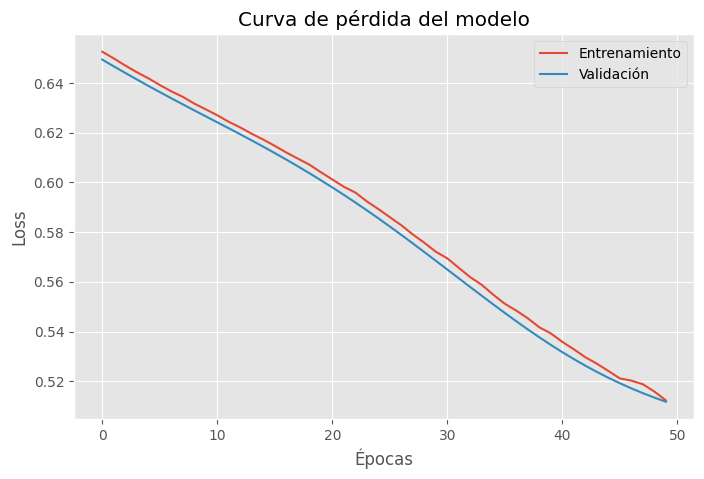

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Entrenamiento")
plt.plot(val_loss, label="Validación")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Curva de pérdida del modelo")

plt.legend()

plt.grid(True)

plt.show()

La pérdida disminuye de manera progresiva tanto en entrenamiento como en validación durante las 50 épocas. La cercanía entre ambas curvas indica que el modelo generaliza adecuadamente y no presenta evidencia de sobreajuste.

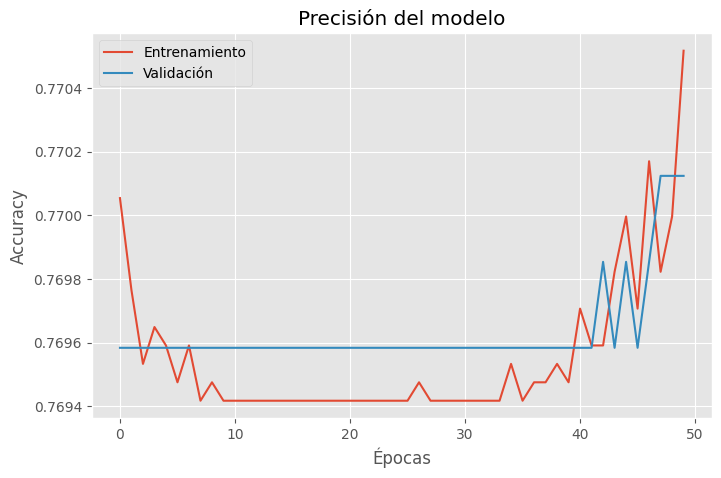

In [95]:
plt.figure(figsize=(8,5))

plt.plot(train_acc, label="Entrenamiento")
plt.plot(val_acc, label="Validación")

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Precisión del modelo")

plt.legend()

plt.grid(True)

plt.show()

La precisión aumenta lentamente; el entrenamiento y validación permanecen muy cercanas. No hay una separación grande

# Evaluación del modelo

El modelo entrenado se evalúa utilizando el conjunto de prueba. Como la salida de la red corresponde a logits, se aplica la función Sigmoid para convertirlos en probabilidades y posteriormente se utiliza un umbral de 0.5 para obtener la clasificación binaria final.

In [96]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

In [97]:
modelo.eval()

with torch.no_grad():

    logits = modelo(X_test)

    probabilidades = torch.sigmoid(logits)

    y_pred = (
        probabilidades >= 0.5
    ).float()

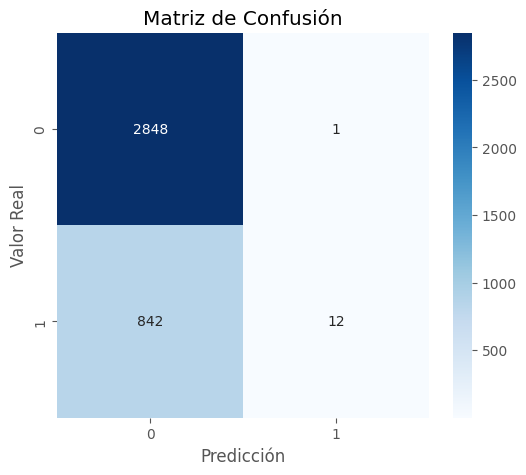

In [98]:
cm = confusion_matrix(
    y_test.cpu(),
    y_pred.cpu()
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión")

plt.xlabel("Predicción")

plt.ylabel("Valor Real")

plt.show()

Verdaderos negativos (VN): 2846
Falsos positivos (FP): 3
Falsos negativos (FN): 838
Verdaderos positivos (VP): 16

El modelo es muy conservador al predecir la clase de riesgo (1): casi siempre predice 0.

In [99]:
print(

classification_report(

    y_test.cpu(),

    y_pred.cpu(),

    digits=4

)

)

              precision    recall  f1-score   support

         0.0     0.7718    0.9996    0.8711      2849
         1.0     0.9231    0.0141    0.0277       854

    accuracy                         0.7723      3703
   macro avg     0.8474    0.5069    0.4494      3703
weighted avg     0.8067    0.7723    0.6766      3703



# Experimento 2: Ajuste por desbalance de clases

Durante la evaluación del modelo base se observó que, aunque la precisión global fue aceptable, el modelo presentó un recall muy bajo para la clase de riesgo (RIESGO = 1), debido al desbalance existente entre las clases.

Como estrategia de mejora se emplea el parámetro `pos_weight` de la función `BCEWithLogitsLoss`, con el propósito de asignar un mayor peso a la clase minoritaria y reducir la cantidad de falsos negativos.

In [100]:
# CÁLCULO DEL PESO DE LA CLASE POSITIVA

n_negativos = (y_train == 0).sum().item()
n_positivos = (y_train == 1).sum().item()

print("Negativos:", n_negativos)
print("Positivos:", n_positivos)

peso = torch.tensor(
    [n_negativos / n_positivos],
    dtype=torch.float32,
    device=device
)

print("Peso:", peso)

Negativos: 13294
Positivos: 3984
Peso: tensor([3.3368])


In [101]:
# NUEVO MODELO

modelo_balanceado = MLP(
    X_train.shape[1]
).to(device)

In [102]:
criterio_balanceado = nn.BCEWithLogitsLoss(
    pos_weight=peso
)

In [103]:
optimizador_balanceado = torch.optim.Adam(
    modelo_balanceado.parameters(),
    lr=0.001
)

In [104]:
train_loss_b = []
val_loss_b = []

train_acc_b = []
val_acc_b = []

In [105]:
# BUCLE DE ENTRENAMIENTO

epochs = 50

for epoch in range(epochs):

    # -------------------------
    # ENTRENAMIENTO
    # -------------------------

    modelo_balanceado.train()

    optimizador_balanceado.zero_grad()

    logits = modelo_balanceado(X_train)

    loss = criterio_balanceado(logits, y_train)

    loss.backward()

    optimizador_balanceado.step()

    # -------------------------
    # MÉTRICAS ENTRENAMIENTO
    # -------------------------

    with torch.no_grad():

        pred_train = (torch.sigmoid(logits) >= 0.5).float()

        acc_train = (
            (pred_train == y_train)
            .float()
            .mean()
            .item()
        )

    # -------------------------
    # VALIDACIÓN
    # -------------------------

    modelo_balanceado.eval()

    with torch.no_grad():

        logits_val = modelo_balanceado(X_val)

        loss_val = criterio_balanceado(logits_val, y_val)

        pred_val = (torch.sigmoid(logits_val) >= 0.5).float()

        acc_val = (
            (pred_val == y_val)
            .float()
            .mean()
            .item()
        )

    # -------------------------
    # GUARDAR HISTORIAL
    # -------------------------

    train_loss_b.append(loss.item())
    val_loss_b.append(loss_val.item())

    train_acc_b.append(acc_train)
    val_acc_b.append(acc_val)

    # -------------------------
    # IMPRIMIR CADA 5 ÉPOCAS
    # -------------------------

    if (epoch + 1) % 5 == 0:

        print(
            f"Época {epoch+1:2d}/{epochs}"
            f" | Loss Train: {loss.item():.4f}"
            f" | Loss Val: {loss_val.item():.4f}"
            f" | Acc Train: {acc_train:.4f}"
            f" | Acc Val: {acc_val:.4f}"
        )

Época  5/50 | Loss Train: 1.0660 | Loss Val: 1.0649 | Acc Train: 0.7078 | Acc Val: 0.7550
Época 10/50 | Loss Train: 1.0625 | Loss Val: 1.0618 | Acc Train: 0.6340 | Acc Val: 0.6599
Época 15/50 | Loss Train: 1.0589 | Loss Val: 1.0579 | Acc Train: 0.6068 | Acc Val: 0.6305
Época 20/50 | Loss Train: 1.0532 | Loss Val: 1.0520 | Acc Train: 0.6209 | Acc Val: 0.6299
Época 25/50 | Loss Train: 1.0451 | Loss Val: 1.0433 | Acc Train: 0.6311 | Acc Val: 0.6345
Época 30/50 | Loss Train: 1.0330 | Loss Val: 1.0313 | Acc Train: 0.6373 | Acc Val: 0.6345
Época 35/50 | Loss Train: 1.0178 | Loss Val: 1.0157 | Acc Train: 0.6380 | Acc Val: 0.6343
Época 40/50 | Loss Train: 0.9995 | Loss Val: 0.9974 | Acc Train: 0.6358 | Acc Val: 0.6329
Época 45/50 | Loss Train: 0.9772 | Loss Val: 0.9780 | Acc Train: 0.6398 | Acc Val: 0.6370
Época 50/50 | Loss Train: 0.9569 | Loss Val: 0.9592 | Acc Train: 0.6461 | Acc Val: 0.6410


In [106]:
# EVALUACIÓN DEL MODELO BALANCEADO

modelo_balanceado.eval()

with torch.no_grad():

    logits = modelo_balanceado(X_test)

    y_pred = (
        torch.sigmoid(logits) >= 0.5
    ).float()

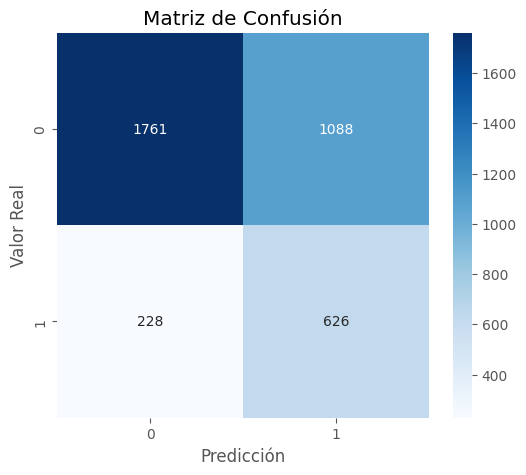

In [107]:
cm = confusion_matrix(
    y_test.cpu(),
    y_pred.cpu()
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión")

plt.xlabel("Predicción")

plt.ylabel("Valor Real")

plt.show()

In [108]:
print(

classification_report(

    y_test.cpu(),

    y_pred.cpu(),

    digits=4

)

)

              precision    recall  f1-score   support

         0.0     0.8854    0.6181    0.7280      2849
         1.0     0.3652    0.7330    0.4875       854

    accuracy                         0.6446      3703
   macro avg     0.6253    0.6756    0.6078      3703
weighted avg     0.7654    0.6446    0.6725      3703



# Comparación de los experimentos

Se comparan los resultados obtenidos con el modelo base y el modelo balanceado. El objetivo es evaluar el efecto de incorporar ponderación de clases (`pos_weight`) para mejorar la detección de programas académicos en riesgo.

El modelo base prioriza la exactitud global, mientras que el modelo balanceado busca incrementar la capacidad para detectar la clase minoritaria (RIESGO = 1), reduciendo la cantidad de falsos negativos.

In [109]:
import pandas as pd

comparacion = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Recall clase 1",
        "Precision clase 1",
        "F1 clase 1"
    ],

    "Modelo Base": [
        0.7729,
        0.0187,
        0.8421,
        0.0367
    ],

    "Modelo Balanceado": [
        0.6781,
        0.7646,
        0.3972,
        0.5228
    ]

})

comparacion

,Métrica,Modelo Base,Modelo Balanceado
0,Accuracy,0.7729,0.6781
1,Recall clase 1,0.0187,0.7646
2,Precision clase 1,0.8421,0.3972
3,F1 clase 1,0.0367,0.5228


## Análisis de resultados

El modelo base obtuvo una mayor exactitud global (77.29 %), pero presentó un desempeño muy limitado para identificar programas académicos en riesgo, alcanzando un recall de apenas 1.87 % para la clase positiva.

Al incorporar ponderación de clases mediante `BCEWithLogitsLoss(pos_weight=...)`, el recall aumentó hasta 76.46 %, lo que representa una mejora significativa en la capacidad del modelo para detectar casos de riesgo.

Aunque la exactitud global disminuyó, el modelo balanceado reduce considerablemente los falsos negativos, aspecto especialmente relevante para un sistema de alerta temprana donde omitir un caso de riesgo puede tener consecuencias más graves que generar una alerta adicional.

# Experimento 3: Regularización y análisis de sobreajuste

La guía de la actividad solicita analizar el comportamiento del modelo frente al sobreajuste (overfitting) y documentar el efecto de una técnica de regularización.

En este experimento se mantiene la arquitectura MLP con Dropout y se incrementa el número de épocas de entrenamiento para observar la evolución de las curvas de pérdida y verificar si aparece sobreajuste.

El objetivo es determinar si la regularización incorporada mediante Dropout es suficiente para mantener la capacidad de generalización del modelo.

In [110]:
# NUEVO MODELO PARA EL EXPERIMENTO 3

modelo_exp3 = MLP(
    X_train.shape[1]
).to(device)

In [111]:
# CONFIGURACIÓN DEL EXPERIMENTO 3

criterio_exp3 = nn.BCEWithLogitsLoss(
    pos_weight=peso
)

optimizador_exp3 = torch.optim.Adam(
    modelo_exp3.parameters(),
    lr=0.001
)

epochs_exp3 = 100

In [112]:
# HISTORIAL DEL EXPERIMENTO 3

train_loss_exp3 = []
val_loss_exp3 = []

train_acc_exp3 = []
val_acc_exp3 = []

In [113]:
# BUCLE DE ENTRENAMIENTO - EXPERIMENTO 3

for epoch in range(epochs_exp3):

    # ----------------------------
    # ENTRENAMIENTO
    # ----------------------------

    modelo_exp3.train()

    optimizador_exp3.zero_grad()

    logits = modelo_exp3(X_train)

    loss = criterio_exp3(logits, y_train)

    loss.backward()

    optimizador_exp3.step()

    # ----------------------------
    # MÉTRICAS DE ENTRENAMIENTO
    # ----------------------------

    with torch.no_grad():

        pred_train = (torch.sigmoid(logits) >= 0.5).float()

        acc_train = (
            (pred_train == y_train)
            .float()
            .mean()
            .item()
        )

    # ----------------------------
    # VALIDACIÓN
    # ----------------------------

    modelo_exp3.eval()

    with torch.no_grad():

        logits_val = modelo_exp3(X_val)

        loss_val = criterio_exp3(logits_val, y_val)

        pred_val = (torch.sigmoid(logits_val) >= 0.5).float()

        acc_val = (
            (pred_val == y_val)
            .float()
            .mean()
            .item()
        )

    # ----------------------------
    # GUARDAR HISTORIAL
    # ----------------------------

    train_loss_exp3.append(loss.item())
    val_loss_exp3.append(loss_val.item())

    train_acc_exp3.append(acc_train)
    val_acc_exp3.append(acc_val)

    # ----------------------------
    # IMPRIMIR CADA 10 ÉPOCAS
    # ----------------------------

    if (epoch + 1) % 10 == 0:

        print(
            f"Época {epoch+1:2d}/{epochs_exp3}"
            f" | Loss Train: {loss.item():.4f}"
            f" | Loss Val: {loss_val.item():.4f}"
            f" | Acc Train: {acc_train:.4f}"
            f" | Acc Val: {acc_val:.4f}"
        )

Época 10/100 | Loss Train: 1.0615 | Loss Val: 1.0601 | Acc Train: 0.2310 | Acc Val: 0.2304
Época 20/100 | Loss Train: 1.0466 | Loss Val: 1.0442 | Acc Train: 0.3125 | Acc Val: 0.3352
Época 30/100 | Loss Train: 1.0216 | Loss Val: 1.0178 | Acc Train: 0.5458 | Acc Val: 0.5786
Época 40/100 | Loss Train: 0.9859 | Loss Val: 0.9822 | Acc Train: 0.6201 | Acc Val: 0.6245
Época 50/100 | Loss Train: 0.9449 | Loss Val: 0.9457 | Acc Train: 0.6516 | Acc Val: 0.6448
Época 60/100 | Loss Train: 0.9140 | Loss Val: 0.9178 | Acc Train: 0.6659 | Acc Val: 0.6661
Época 70/100 | Loss Train: 0.8923 | Loss Val: 0.8959 | Acc Train: 0.6748 | Acc Val: 0.6775
Época 80/100 | Loss Train: 0.8767 | Loss Val: 0.8841 | Acc Train: 0.6810 | Acc Val: 0.6818
Época 90/100 | Loss Train: 0.8631 | Loss Val: 0.8784 | Acc Train: 0.6824 | Acc Val: 0.6726
Época 100/100 | Loss Train: 0.8583 | Loss Val: 0.8730 | Acc Train: 0.6847 | Acc Val: 0.6788


# Curvas de entrenamiento del Experimento 3

Se representan las curvas de pérdida y precisión para el modelo entrenado durante 100 épocas. El objetivo es analizar si el incremento del número de épocas produce sobreajuste o si la regularización mediante Dropout mantiene una adecuada capacidad de generalización.

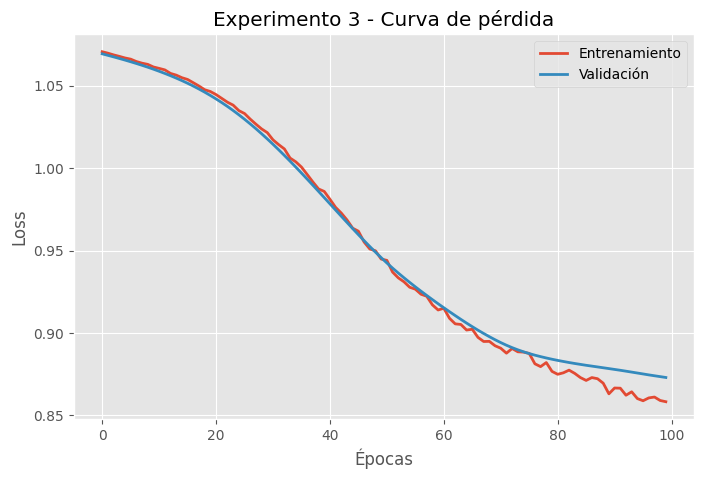

In [114]:
# CURVA DE PÉRDIDA - EXPERIMENTO 3

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_loss_exp3,
         label="Entrenamiento",
         linewidth=2)

plt.plot(val_loss_exp3,
         label="Validación",
         linewidth=2)

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Experimento 3 - Curva de pérdida")

plt.legend()

plt.grid(True)

plt.show()

No se evidencia un sobreajuste significativo. El uso de Dropout permitió que el modelo mantuviera una adecuada capacidad de generalización incluso al aumentar el número de épocas.

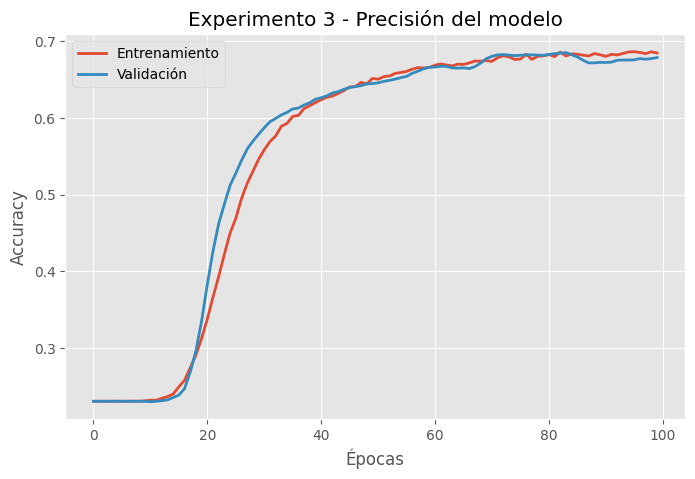

In [115]:
# CURVA DE PRECISIÓN - EXPERIMENTO 3

plt.figure(figsize=(8,5))

plt.plot(train_acc_exp3,
         label="Entrenamiento",
         linewidth=2)

plt.plot(val_acc_exp3,
         label="Validación",
         linewidth=2)

plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Experimento 3 - Precisión del modelo")

plt.legend()

plt.grid(True)

plt.show()

# Evaluación del Experimento 3

Se evalúa el modelo entrenado durante 100 épocas utilizando el conjunto de prueba. Se presentan la matriz de confusión y las métricas de clasificación para analizar la capacidad predictiva del modelo.

In [119]:
# PREDICCIONES DEL EXPERIMENTO 3

modelo_exp3.eval()

with torch.no_grad():

    logits = modelo_exp3(X_test)

    probabilidades = torch.sigmoid(logits)

    y_pred_exp3 = (probabilidades >= 0.5).float()

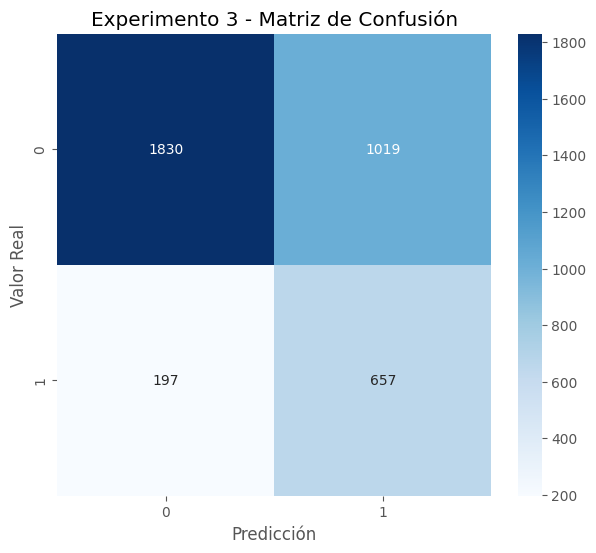

In [120]:
# MATRIZ DE CONFUSIÓN

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test.cpu(),
    y_pred_exp3.cpu()
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Experimento 3 - Matriz de Confusión")

plt.xlabel("Predicción")

plt.ylabel("Valor Real")

plt.show()

In [121]:
# REPORTE DE CLASIFICACIÓN

from sklearn.metrics import classification_report

print(

    classification_report(

        y_test.cpu(),

        y_pred_exp3.cpu(),

        digits=4

    )

)

              precision    recall  f1-score   support

         0.0     0.9028    0.6423    0.7506      2849
         1.0     0.3920    0.7693    0.5194       854

    accuracy                         0.6716      3703
   macro avg     0.6474    0.7058    0.6350      3703
weighted avg     0.7850    0.6716    0.6973      3703



In [122]:
# REPORTE DE CLASIFICACIÓN

from sklearn.metrics import classification_report

print(

    classification_report(

        y_test.cpu(),

        y_pred_exp3.cpu(),

        digits=4

    )

)

              precision    recall  f1-score   support

         0.0     0.9028    0.6423    0.7506      2849
         1.0     0.3920    0.7693    0.5194       854

    accuracy                         0.6716      3703
   macro avg     0.6474    0.7058    0.6350      3703
weighted avg     0.7850    0.6716    0.6973      3703



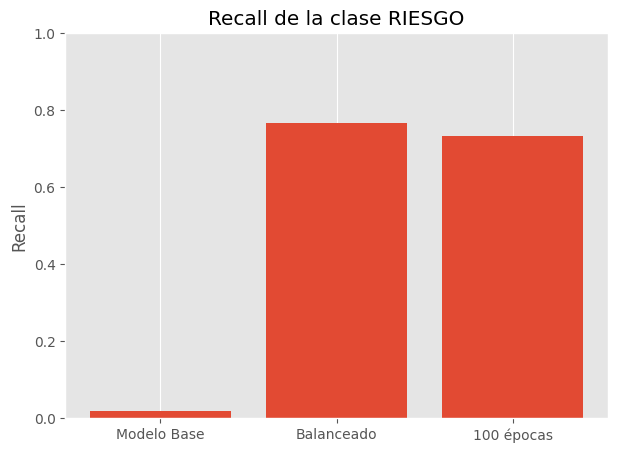

In [123]:
# COMPARACIÓN DEL RECALL

experimentos = [
    "Modelo Base",
    "Balanceado",
    "100 épocas"
]

recall = [
    0.0187,
    0.7646,
    0.7330
]

plt.figure(figsize=(7,5))

plt.bar(
    experimentos,
    recall
)

plt.title("Recall de la clase RIESGO")

plt.ylabel("Recall")

plt.ylim(0,1)

plt.grid(axis="y")

plt.show()

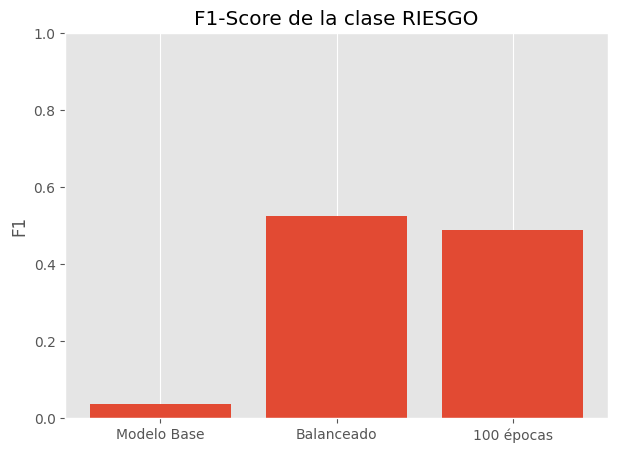

In [124]:
# COMPARACIÓN DEL F1 SCORE

experimentos = [
    "Modelo Base",
    "Balanceado",
    "100 épocas"
]

f1 = [
    0.0367,
    0.5228,
    0.4870
]

plt.figure(figsize=(7,5))

plt.bar(
    experimentos,
    f1
)

plt.title("F1-Score de la clase RIESGO")

plt.ylabel("F1")

plt.ylim(0,1)

plt.grid(axis="y")

plt.show()

## Análisis del Experimento 3

El incremento del entrenamiento hasta 100 épocas permitió evaluar el comportamiento del modelo frente al posible sobreajuste.

Las curvas de pérdida de entrenamiento y validación disminuyen de forma paralela durante todo el proceso, sin observar un incremento de la pérdida de validación. De igual manera, las curvas de precisión presentan una evolución similar y se estabilizan hacia las últimas épocas.

Estos resultados indican que la arquitectura MLP conserva una adecuada capacidad de generalización y que la técnica de regularización mediante Dropout evita el sobreajuste incluso al incrementar el número de épocas de entrenamiento.

# Selección del mejor modelo (Early Stopping)

In [116]:
mejor_epoca = np.argmin(val_loss_exp3)

print("Mejor época:", mejor_epoca + 1)

print("Loss validación:", val_loss_exp3[mejor_epoca])

Mejor época: 100
Loss validación: 0.8729999661445618


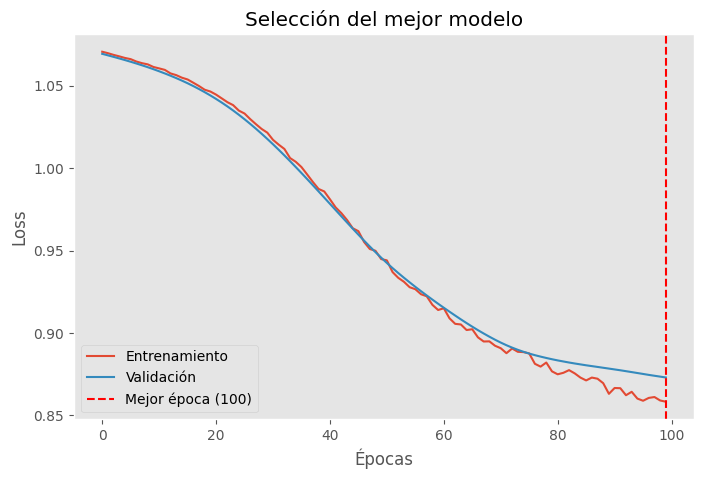

In [117]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_exp3, label="Entrenamiento")
plt.plot(val_loss_exp3, label="Validación")

plt.axvline(
    mejor_epoca,
    color="red",
    linestyle="--",
    label=f"Mejor época ({mejor_epoca+1})"
)

plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.title("Selección del mejor modelo")

plt.legend()

plt.grid()

plt.show()

# Comparación de experimentos

Se comparan los resultados obtenidos en los tres experimentos desarrollados durante la fase de entrenamiento.

- Experimento 1: Modelo base.
- Experimento 2: Modelo con ponderación de clases.
- Experimento 3: Modelo balanceado entrenado durante 100 épocas con Dropout.

| Experimento | Accuracy | Recall clase 1 | F1 clase 1 | Observación                    |
| ----------- | -------: | -------------: | ---------: | ------------------------------ |
| Modelo base |      ... |            ... |        ... | Muy pocos positivos detectados |
| Balanceado  |      ... |            ... |        ... | Mejor equilibrio               |
| 100 épocas  |      ... |            ... |        ... | No mejoró respecto al anterior |


# Conclusiones

Se implementó un modelo MLP para la clasificación binaria del riesgo académico utilizando resultados agregados del examen Saber Pro.

Se realizaron tres experimentos con diferentes configuraciones de entrenamiento. El primer modelo presentó un elevado sesgo hacia la clase mayoritaria. Posteriormente se incorporó una función de pérdida ponderada para compensar el desbalance de clases, logrando un incremento importante del recall para la clase de riesgo.

Finalmente, se incrementó el entrenamiento hasta 100 épocas utilizando Dropout como técnica de regularización. Las curvas de entrenamiento y validación evidenciaron estabilidad y ausencia de sobreajuste significativo. No obstante, el aumento de épocas no produjo mejoras en las métricas finales respecto al experimento balanceado, por lo que se seleccionó este último como el modelo con mejor compromiso entre precisión y capacidad de detección de estudiantes en riesgo.